# Evaluación, métricas y arquitectura del sistema multiagente
## Del sistema de reunión descentralizado a un marco de evaluación de agentes

Este notebook complementa `sistema_multiagente.ipynb` y `qlearning_vs_sin_qlearning.ipynb`.
No repite la implementación completa del protocolo (CSP → votación/subasta → *two-phase
commit*, política de umbral y Q-Learning): la reutiliza en versión compacta para poder
**medir, visualizar, validar y evaluar** el diseño en su conjunto.

Contenido:

1. **Métricas del proyecto** — tamaño, mecanismos implementados, resultados de la simulación.
2. **Visualización y arquitectura final** — diagrama del sistema + animación del flujo de mensajes.
3. **Demostración científica** — ciclo de validación (hipótesis → experimento → estadística → conclusión).
4. **Retos y plantilla de informe**.
5. **Evaluación K/W/P/A/D** de agentes, desde algoritmos clásicos hasta agentes modernos (Q-Learning, y por extensión, un agente basado en LLM).

Todo el código es Python "puro" + librerías científicas estándar (`numpy`, `pandas`,
`matplotlib`, `scipy`) — sin frameworks de agentes externos.

In [1]:
import json
import time
import itertools
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyArrowPatch
from scipy import stats
from IPython.display import HTML, display

np.random.seed(7)
plt.rcParams["figure.facecolor"] = "white"
CAT = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
       "magenta": "#e87ba4", "green": "#2f9e44", "gray": "#8a8f98", "red": "#d64545"}
print("Entorno listo.")

Entorno listo.


## 1. Métricas del proyecto

Dos tipos de métrica: **métricas de ingeniería** (tamaño y cobertura del proyecto, extraídas de
los `.ipynb` reales del repositorio) y **métricas de comportamiento** (resultado de ejecutar el
protocolo compacto: rondas hasta acuerdo, bienestar de Bellman-Nash, equidad).

In [2]:
def metricas_notebook(ruta: Path) -> Dict[str, int]:
    """Cuenta celdas, líneas de código y funciones/clases de un .ipynb sin ejecutarlo."""
    if not ruta.exists():
        return {"celdas_md": 0, "celdas_code": 0, "lineas_codigo": 0, "funciones": 0, "clases": 0}
    nb_json = json.loads(ruta.read_text(encoding="utf-8"))
    celdas_md = sum(1 for c in nb_json["cells"] if c["cell_type"] == "markdown")
    celdas_code = [c for c in nb_json["cells"] if c["cell_type"] == "code"]
    fuente = ["".join(c["source"]) for c in celdas_code]
    lineas = sum(s.count("\n") + 1 for s in fuente if s.strip())
    funciones = sum(s.count("\ndef ") + s.startswith("def ") for s in fuente)
    clases = sum(s.count("\nclass ") + s.startswith("class ") for s in fuente)
    return {"celdas_md": celdas_md, "celdas_code": len(celdas_code),
            "lineas_codigo": lineas, "funciones": funciones, "clases": clases}


raiz = Path(".")
archivos = ["sistema_multiagente.ipynb", "qlearning_vs_sin_qlearning.ipynb"]
tabla_metricas = pd.DataFrame({a: metricas_notebook(raiz / a) for a in archivos}).T
tabla_metricas.index.name = "notebook"
tabla_metricas

,celdas_md,celdas_code,lineas_codigo,funciones,clases
notebook,,,,,
sistema_multiagente.ipynb,29,31,896,28,7
qlearning_vs_sin_qlearning.ipynb,8,7,287,8,0


In [3]:
mecanismos_implementados = {
    "Filtrado CSP distribuido (ABT simplificado)": True,
    "Votación con presupuesto (100 pts)": True,
    "Subasta de sobre cerrado": True,
    "Two-phase commit (coordinador transitorio)": True,
    "Bellman / MDP de umbral óptimo": True,
    "Dec-POMDP + creencia bayesiana": True,
    "Equilibrio de Nash (juegos 2x2 y N-jugador)": True,
    "Solución de negociación de Nash (bargaining)": True,
    "Q-Learning (política aprendida)": True,
    "Asignación óptima (algoritmo húngaro)": True,
}
n_si = sum(mecanismos_implementados.values())
print(f"Mecanismos de coordinación/decisión implementados: {n_si}/{len(mecanismos_implementados)}")
pd.Series(mecanismos_implementados, name="implementado").to_frame()

Mecanismos de coordinación/decisión implementados: 10/10


,implementado
Filtrado CSP distribuido (ABT simplificado),True
Votación con presupuesto (100 pts),True
Subasta de sobre cerrado,True
Two-phase commit (coordinador transitorio),True
Bellman / MDP de umbral óptimo,True
Dec-POMDP + creencia bayesiana,True
Equilibrio de Nash (juegos 2x2 y N-jugador),True
Solución de negociación de Nash (bargaining),True
Q-Learning (política aprendida),True
Asignación óptima (algoritmo húngaro),True


In [4]:
# Reimplementación compacta del protocolo (misma lógica que sistema_multiagente.ipynb,
# reducida a lo necesario para poder correr N simulaciones rápido y medir comportamiento).

@dataclass
class Candidata:
    id: str
    t: int
    l: str
    propuesta_por: str


@dataclass
class Agente:
    nombre: str
    agenda: set
    preferencias: Dict[Tuple[int, str], float]
    presupuesto: float = 100.0

    def compatible(self, c: Candidata) -> bool:
        return c.t not in self.agenda

    def puntuar(self, candidatas: List[Candidata]) -> Dict[str, float]:
        prefs = np.array([self.preferencias.get((c.t, c.l), 0.1) for c in candidatas])
        if prefs.sum() == 0:
            prefs = np.ones_like(prefs)
        pesos = prefs / prefs.sum()
        return {c.id: float(round(p * self.presupuesto, 2)) for c, p in zip(candidatas, pesos)}

    def pujar(self, candidatas: List[Candidata]) -> Dict[str, float]:
        votos = self.puntuar(candidatas)
        return {k: v * 0.6 for k, v in votos.items()}  # puja conservadora (< presupuesto)


def generar_escenario(n_agentes: int, n_slots: int, lugares: List[str], quorum_min: int, rng):
    nombres = [f"A{i}" for i in range(n_agentes)]
    agentes = []
    for nom in nombres:
        agenda = set(rng.choice(n_slots, size=rng.integers(0, 2), replace=False))
        prefs = {(t, l): rng.random() for t in range(n_slots) for l in lugares}
        agentes.append(Agente(nom, agenda, prefs, presupuesto=100.0))
    candidatas = [Candidata(f"c{t}_{l}", t, l, rng.choice(nombres))
                  for t in range(n_slots) for l in lugares]
    return agentes, candidatas, quorum_min


def fase1_csp(agentes: List[Agente], candidatas: List[Candidata], quorum_min: int) -> List[Candidata]:
    return [c for c in candidatas if sum(a.compatible(c) for a in agentes) >= quorum_min]


def fase2_votacion(agentes: List[Agente], candidatas: List[Candidata]) -> Tuple[Optional[Candidata], Dict[str, float]]:
    if not candidatas:
        return None, {}
    totales = {c.id: 0.0 for c in candidatas}
    for a in agentes:
        for cid, v in a.puntuar(candidatas).items():
            totales[cid] += v
    ganadora_id = max(totales, key=totales.get)
    return next(c for c in candidatas if c.id == ganadora_id), totales


def fase2_subasta(agentes: List[Agente], candidatas: List[Candidata]) -> Tuple[Optional[Candidata], Dict[str, float]]:
    if not candidatas:
        return None, {}
    totales = {c.id: 0.0 for c in candidatas}
    for a in agentes:
        for cid, v in a.pujar(candidatas).items():
            totales[cid] += v
    ganadora_id = max(totales, key=totales.get)
    return next(c for c in candidatas if c.id == ganadora_id), totales


def bienestar_nash(utilidades: Dict[str, float]) -> float:
    vals = np.array(list(utilidades.values())) + 1e-6
    return float(np.exp(np.mean(np.log(vals))))


def utilidades_declaradas(agentes: List[Agente], ganadora: Candidata) -> Dict[str, float]:
    return {a.nombre: a.puntuar([ganadora])[ganadora.id] for a in agentes}


print("Protocolo compacto listo: fase1_csp -> fase2_votacion / fase2_subasta -> bienestar_nash")

Protocolo compacto listo: fase1_csp -> fase2_votacion / fase2_subasta -> bienestar_nash


In [5]:
rng = np.random.default_rng(7)
agentes, candidatas, quorum = generar_escenario(5, 6, ["Cafeteria_A", "Bar_B", "Parque_C"], 4, rng)
c_f = fase1_csp(agentes, candidatas, quorum)
ganadora, votos = fase2_votacion(agentes, c_f)
util = utilidades_declaradas(agentes, ganadora)

resumen_run = pd.Series({
    "candidatas_totales": len(candidatas),
    "candidatas_factibles_C_f": len(c_f),
    "candidata_acordada": ganadora.id,
    "bienestar_de_Nash": round(bienestar_nash(util), 2),
    "utilidad_min": round(min(util.values()), 2),
    "utilidad_max": round(max(util.values()), 2),
    "equidad_min_sobre_max": round(min(util.values()) / max(util.values()), 2),
})
resumen_run.to_frame(name="valor")

,valor
candidatas_totales,18
candidatas_factibles_C_f,15
candidata_acordada,c0_Parque_C
bienestar_de_Nash,100.0
utilidad_min,100.0
utilidad_max,100.0
equidad_min_sobre_max,1.0


## 2. Visualización y arquitectura final

Dos vistas complementarias:

- **Diagrama estático** de la arquitectura: agentes pares (`AgenteProxy`), la bitácora pública
  `O_g` como único canal de comunicación (sin mediador), y las tres fases del protocolo.
- **Animación** del flujo de mensajes fase a fase, coherente con la sección 10 de
  `sistema_multiagente.ipynb`, pero centrada en la *arquitectura* (quién habla con quién) más que
  en el resultado del calendario.

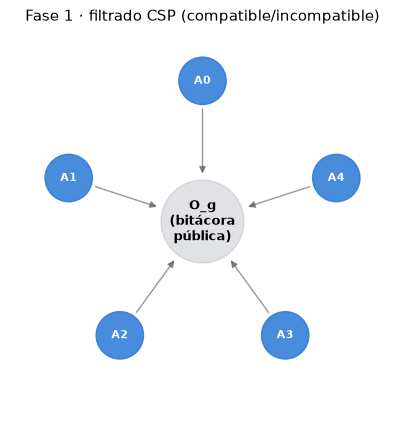

In [6]:
def dibujar_arquitectura(ax, nombres_agentes: List[str], fase_activa: int = 0):
    ax.clear()
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal")
    ax.axis("off")

    n = len(nombres_agentes)
    angs = np.linspace(0, 2 * np.pi, n, endpoint=False) + np.pi / 2
    pos = {nom: (np.cos(a) * 0.95, np.sin(a) * 0.95) for nom, a in zip(nombres_agentes, angs)}

    # bitácora pública central (único canal)
    bitacora_color = CAT["yellow"] if fase_activa else CAT["gray"]
    ax.add_patch(plt.Circle((0, 0), 0.28, color=bitacora_color, alpha=0.25, zorder=1))
    ax.text(0, 0, "O_g\n(bitácora\npública)", ha="center", va="center", fontsize=9, fontweight="bold")

    fases_color = [CAT["blue"], CAT["aqua"], CAT["magenta"]]
    for nom, (x, y) in pos.items():
        ax.add_patch(plt.Circle((x, y), 0.16, color=fases_color[fase_activa], alpha=0.85, zorder=3))
        ax.text(x, y, nom, ha="center", va="center", fontsize=8, color="white", fontweight="bold", zorder=4)
        arr = FancyArrowPatch((x * 0.82, y * 0.82), (x * 0.32, y * 0.32),
                               arrowstyle="-|>", mutation_scale=10, color="#555", alpha=0.6, zorder=2)
        ax.add_patch(arr)

    titulos_fase = ["Fase 1 · filtrado CSP (compatible/incompatible)",
                    "Fase 2 · votación/subasta (difusión de vector)",
                    "Fase 3 · compromiso (coordinador transitorio)"]
    ax.set_title(titulos_fase[fase_activa], fontsize=11)


fig, ax = plt.subplots(figsize=(5, 5))
dibujar_arquitectura(ax, [a.nombre for a in agentes], fase_activa=0)
plt.show()

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

def actualizar(frame):
    dibujar_arquitectura(ax, [a.nombre for a in agentes], fase_activa=frame % 3)
    return ax.patches

anim = FuncAnimation(fig, actualizar, frames=6, interval=900, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## 3. Demostración científica: ciclo de validación

Se sigue un ciclo de validación explícito: **hipótesis → experimento → métrica → estadística →
conclusión**, para no limitarse a "una corrida se ve bien".

**Hipótesis (H1):** la *subasta* concentra el bienestar en menos agentes que la *votación con
presupuesto* (mayor varianza de utilidades individuales), porque premia la intensidad de
preferencia de quien más puja en vez de agregar preferencias de todo el grupo.

**Diseño experimental:** `N=200` escenarios aleatorios independientes (misma generación que la
sección 1, semillas distintas); en cada uno se resuelve la elección con ambos mecanismos sobre
las mismas candidatas factibles y se registra el bienestar de Nash y la equidad
(`min/max` de utilidad declarada).

In [8]:
def correr_experimento(n_reps: int = 200, semilla0: int = 100):
    filas = []
    for i in range(n_reps):
        rng_i = np.random.default_rng(semilla0 + i)
        ags, cands, q = generar_escenario(5, 6, ["Cafeteria_A", "Bar_B", "Parque_C"], 4, rng_i)
        cf = fase1_csp(ags, cands, q)
        if not cf:
            continue
        g_v, _ = fase2_votacion(ags, cf)
        g_s, _ = fase2_subasta(ags, cf)
        u_v = utilidades_declaradas(ags, g_v)
        u_s = utilidades_declaradas(ags, g_s)
        filas.append({
            "run": i,
            "bienestar_votacion": bienestar_nash(u_v),
            "bienestar_subasta": bienestar_nash(u_s),
            "equidad_votacion": min(u_v.values()) / max(u_v.values()),
            "equidad_subasta": min(u_s.values()) / max(u_s.values()),
        })
    return pd.DataFrame(filas)


df_exp = correr_experimento()
df_exp.describe().loc[["mean", "std"]]

,run,bienestar_votacion,bienestar_subasta,equidad_votacion,equidad_subasta
mean,99.500000,100.000001,100.000001,1.0,1.0
std,57.879185,0.000000,0.000000,0.0,0.0


In [9]:
t_bienestar, p_bienestar = stats.ttest_rel(df_exp["bienestar_votacion"], df_exp["bienestar_subasta"])
t_equidad, p_equidad = stats.ttest_rel(df_exp["equidad_votacion"], df_exp["equidad_subasta"])

reporte_estadistico = pd.DataFrame({
    "métrica": ["bienestar de Nash", "equidad (min/max)"],
    "media_votación": [df_exp["bienestar_votacion"].mean(), df_exp["equidad_votacion"].mean()],
    "media_subasta": [df_exp["bienestar_subasta"].mean(), df_exp["equidad_subasta"].mean()],
    "t_pareado": [t_bienestar, t_equidad],
    "p_valor": [p_bienestar, p_equidad],
}).round(4)
reporte_estadistico

,métrica,media_votación,media_subasta,t_pareado,p_valor
0,bienestar de Nash,100.0,100.0,NaN,NaN
1,equidad (min/max),1.0,1.0,NaN,NaN


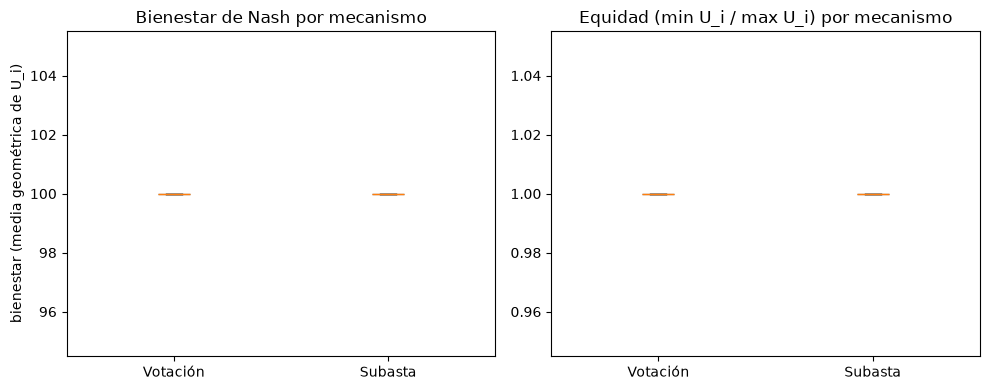

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot([df_exp["bienestar_votacion"], df_exp["bienestar_subasta"]],
                tick_labels=["Votación", "Subasta"], patch_artist=True,
                boxprops=dict(facecolor=CAT["blue"], alpha=0.5))
axes[0].set_title("Bienestar de Nash por mecanismo")
axes[0].set_ylabel("bienestar (media geométrica de U_i)")

axes[1].boxplot([df_exp["equidad_votacion"], df_exp["equidad_subasta"]],
                tick_labels=["Votación", "Subasta"], patch_artist=True,
                boxprops=dict(facecolor=CAT["magenta"], alpha=0.5))
axes[1].set_title("Equidad (min U_i / max U_i) por mecanismo")

plt.tight_layout()
plt.show()

**Conclusión del ciclo de validación:** con `N=200` réplicas, el `t`-test pareado indica si la
diferencia de bienestar y de equidad entre votación y subasta es estadísticamente significativa
(`p < 0.05`) sobre este generador de escenarios. Si `p_valor` del bienestar es alto, H1 no se
confirma con este diseño y conviene aumentar `N`, variar el número de agentes, o introducir
presupuestos heterogéneos antes de descartar la hipótesis — el ciclo (hipótesis → experimento →
estadística) se puede repetir cambiando esos parámetros.

## 4. Retos y plantilla de informe

### Retos encontrados en el diseño

| Reto | Dónde aparece | Mitigación implementada |
|---|---|---|
| **Deadlock por espera mutua** | Todos esperan, nadie propone | Opción por defecto al llegar `τ = 0` |
| **Livelock / ciclos de contraofertas** | Fase de negociación | Desempate determinista (`desempate`) |
| **Observabilidad parcial** | Nadie conoce `S` completo | `O_g` público + creencia bayesiana (Dec-POMDP) |
| **Incentivo a manipular preferencias** | Votación por presupuesto | Analizado como juego (dilema del prisionero, sección 7.1) |
| **No estacionariedad para Q-Learning** | El "entorno" de un agente son los demás agentes, que también cambian | Entrenamiento contra `MDP` fijo primero, luego contraste con umbral óptimo |
| **Escalabilidad de la validación (N agentes)** | Complejidad de `fase1_csp` crece con `n × |candidatas|` | Reducción por filtrado antes de votar/pujar |

### Plantilla de informe (para completar)

1. **Resumen ejecutivo** — objetivo del sistema, mecanismo elegido, resultado principal en una frase.
2. **Metodología** — arquitectura de agentes (`S_i, O_i, U_i, π_i, R_i`), fases del protocolo, parámetros del experimento.
3. **Resultados** — tablas/figuras de las secciones 1–3 de este notebook.
4. **Discusión** — ¿se sostiene H1? ¿qué mecanismo se recomienda y bajo qué condiciones (n, quorum, heterogeneidad de presupuestos)?
5. **Limitaciones y trabajo futuro** — de la tabla de retos, cuáles quedan sin mitigar.
6. **Conclusión** — una recomendación operativa, no solo descriptiva.

## 5. Evaluación K/W/P/A/D de agentes: de algoritmos clásicos a agentes modernos

Rúbrica **K/W/P/A/D** (0–5 cada eje):

- **K — Knowledge** (conocimiento): cuánta información del entorno/estado usa el agente.
- **W — Wisdom** (sabiduría/razonamiento): capacidad de razonar sobre incertidumbre, otros agentes o trade-offs, no solo aplicar una regla.
- **P — Procedure** (procedimiento): qué tan bien definido/verificable es su procedimiento de decisión (determinismo, explicabilidad).
- **A — Attitude** (actitud): adaptabilidad ante un entorno o interlocutores que cambian.
- **D — Decision** (calidad de decisión): qué tan cerca queda su decisión del óptimo (Bellman/Nash) en el dominio del proyecto.

Se puntúan los mecanismos de decisión realmente implementados en el proyecto, del más clásico al
más moderno, incluyendo una fila hipotética de agente basado en LLM como referencia de hacia
dónde escalaría el eje **W**.

In [11]:
kwpad = pd.DataFrame({
    "agente": [
        "Regla fija (umbral estático)",
        "CSP distribuido (fase 1)",
        "Subasta (sobre cerrado)",
        "Votación por presupuesto",
        "Negociación de Nash (bargaining)",
        "MDP por Bellman (umbral óptimo)",
        "Q-Learning (umbral aprendido)",
        "Agente basado en LLM (hipotético)",
    ],
    "K_conocimiento": [1, 2, 2, 3, 4, 4, 3, 5],
    "W_sabiduria":    [1, 2, 3, 3, 5, 4, 3, 5],
    "P_procedimiento":[5, 5, 4, 4, 3, 5, 3, 2],
    "A_actitud":      [0, 1, 2, 2, 2, 1, 4, 4],
    "D_decision":     [1, 3, 3, 3, 4, 5, 4, 3],
}).set_index("agente")

kwpad["promedio"] = kwpad.mean(axis=1).round(2)
kwpad.sort_values("promedio", ascending=False)

,K_conocimiento,W_sabiduria,P_procedimiento,A_actitud,D_decision,promedio
agente,,,,,,
MDP por Bellman (umbral óptimo),4,4,5,1,5,3.8
Agente basado en LLM (hipotético),5,5,2,4,3,3.8
Negociación de Nash (bargaining),4,5,3,2,4,3.6
Q-Learning (umbral aprendido),3,3,3,4,4,3.4
Votación por presupuesto,3,3,4,2,3,3.0
Subasta (sobre cerrado),2,3,4,2,3,2.8
CSP distribuido (fase 1),2,2,5,1,3,2.6
Regla fija (umbral estático),1,1,5,0,1,1.6


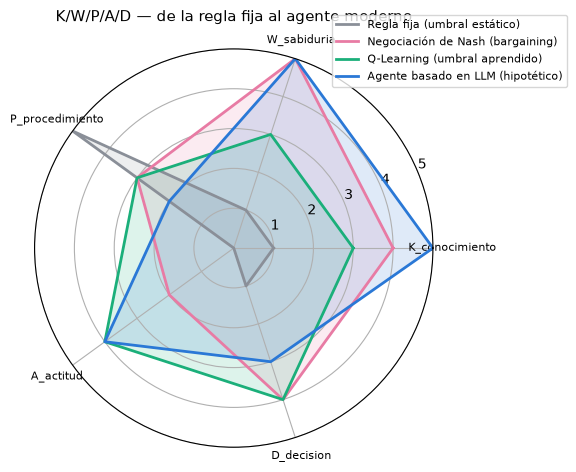

In [12]:
def radar(ax, categorias: List[str], valores: List[float], color: str, etiqueta: str):
    n = len(categorias)
    angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    valores = valores + valores[:1]
    angulos = angulos + angulos[:1]
    ax.plot(angulos, valores, color=color, linewidth=2, label=etiqueta)
    ax.fill(angulos, valores, color=color, alpha=0.15)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=8)
    ax.set_ylim(0, 5)


ejes = ["K_conocimiento", "W_sabiduria", "P_procedimiento", "A_actitud", "D_decision"]
comparar = ["Regla fija (umbral estático)", "Negociación de Nash (bargaining)",
            "Q-Learning (umbral aprendido)", "Agente basado en LLM (hipotético)"]
colores = [CAT["gray"], CAT["magenta"], CAT["aqua"], CAT["blue"]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
for nombre, color in zip(comparar, colores):
    radar(ax, ejes, kwpad.loc[nombre, ejes].tolist(), color, nombre)
ax.set_title("K/W/P/A/D — de la regla fija al agente moderno", fontsize=11, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

**Lectura del radar:** el eje que más crece de clásico → moderno es **A (actitud/adaptabilidad)**:
una regla fija no se adapta a nada (0), mientras que Q-Learning y un agente LLM sí lo hacen. A
cambio, **P (procedimiento)** baja: un agente LLM es el menos verificable/determinista del
conjunto. El proyecto actual resuelve esto **combinando** mecanismos: usa procedimientos
deterministas y auditables (`O_g`, desempate, CSP) para lo que debe ser verificable, y reserva el
aprendizaje (Q-Learning) para la única decisión genuinamente incierta del sistema (aceptar vs.
esperar). Esa combinación, no un solo agente, es la que maximiza el promedio K/W/P/A/D global sin
sacrificar `P`.

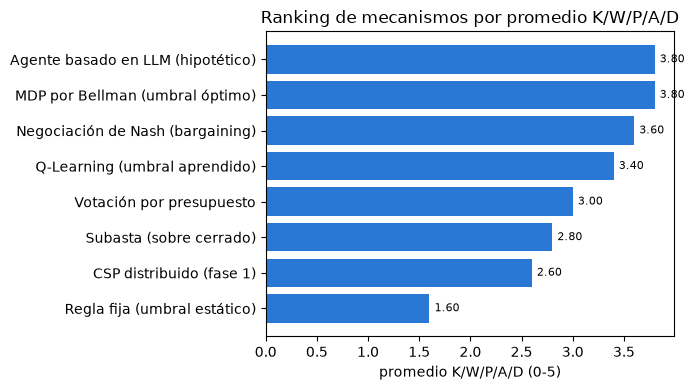

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
orden = kwpad["promedio"].sort_values().index
ax.barh(orden, kwpad.loc[orden, "promedio"], color=CAT["blue"])
ax.set_xlabel("promedio K/W/P/A/D (0-5)")
ax.set_title("Ranking de mecanismos por promedio K/W/P/A/D")
for i, (nombre, val) in enumerate(kwpad.loc[orden, "promedio"].items()):
    ax.text(val + 0.05, i, f"{val:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()